# Statystyczna analiza danych


**Cel:** analiza statystyczna zbioru danych z użyciem metod:
- statystyka opisowa,
- estymacja przedziałowa,
- test parametryczny (t-Studenta / Welch),
- test nieparametryczny (χ² niezależności),
- ANOVA

## Dane
Dane pochodza z platformy kaggle: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?select=penguins_size.csv

Zbiór `penguins_size.csv` zawiera zmienne:
- `species` (Adélie, Chinstrap, Gentoo),
- `culmen_length_mm`, `culmen_depth_mm`,
- `flipper_length_mm`,
- `body_mass_g`,
- `island` (Dream, Torgersen, Biscoe),
- `sex` (male/female).

In [ ]:
# Importy i ustawienia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 100)

## 1. Wczytanie danych i wstępne sprawdzenie

W tej części:
- wczytujemy dane,
- sprawdzamy typy i liczbę obserwacji,
- identyfikujemy braki danych.

In [2]:
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [5]:
df[
    df[[
        "culmen_length_mm",
        "culmen_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]].isna().any(axis=1)
]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [6]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [7]:
df["sex"] = df["sex"].replace(".", np.nan)

## 2. Obsługa braków danych

W danych występują:
- 2 obserwacje bez kompletu pomiarów (brak `culmen_*`, `flipper_length_mm`, `body_mass_g`) – takie rekordy usuwamy zawsze,
- braki w `sex` – usuwamy je tylko w analizach, w których płeć jest potrzebna (test t, regresja z `sex`).


In [8]:
# usuwamy dwa puste rekordy pomiarowe
measure_cols = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_measure = df.dropna(subset=measure_cols).copy()

# typy kategorii
for col in ["species", "island", "sex"]:
    df_measure[col] = df_measure[col].astype("category")

df_measure.shape, df.shape

((342, 7), (344, 7))

In [9]:
df_measure.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

In [10]:
# Zbiór do analiz z sex
df_sex = df_measure.dropna(subset=["sex"]).copy()
df_sex["sex"] = df_sex["sex"].astype("category")

df_sex.shape

(333, 7)

In [11]:
df_sex["sex"].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

## 3. Statystyka opisowa

Wyznaczamy podstawowe miary:
- średnia, mediana,
- wariancja i odchylenie standardowe,
- min/max, kwartyle, IQR,
- skośność i kurtoza (jako miary kształtu rozkładu).

Analizy wykonujemy na zbiorze `df_measure` (po usunięciu pustych rekordów pomiarowych).

In [12]:
# Statystyki opisowe, numeryczne
num_cols = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_measure[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [13]:
desc = pd.DataFrame(index=num_cols)
desc["mean"] = df_measure[num_cols].mean()
desc["median"] = df_measure[num_cols].median()
desc["std"] = df_measure[num_cols].std(ddof=1)
desc["var"] = df_measure[num_cols].var(ddof=1)
desc["min"] = df_measure[num_cols].min()
desc["max"] = df_measure[num_cols].max()
desc["IQR"] = df_measure[num_cols].quantile(0.75) - df_measure[num_cols].quantile(0.25)
desc["skew"] = df_measure[num_cols].skew()
desc["kurtosis"] = df_measure[num_cols].kurtosis()
desc

,mean,median,std,var,min,max,IQR,skew,kurtosis
culmen_length_mm,43.921930,44.45,5.459584,29.807054,32.1,59.6,9.275,0.053118,-0.876027
culmen_depth_mm,17.151170,17.30,1.974793,3.899808,13.1,21.5,3.100,-0.143465,-0.906866
flipper_length_mm,200.915205,197.00,14.061714,197.731792,172.0,231.0,23.000,0.345682,-0.984273
body_mass_g,4201.754386,4050.00,801.954536,643131.077327,2700.0,6300.0,1200.000,0.470329,-0.719222


## 4. Wizualizacja rozkładów

Wykonujemy histogramy dla zmiennych liczbowych oraz boxploty dla masy ciała względem gatunku i płci.

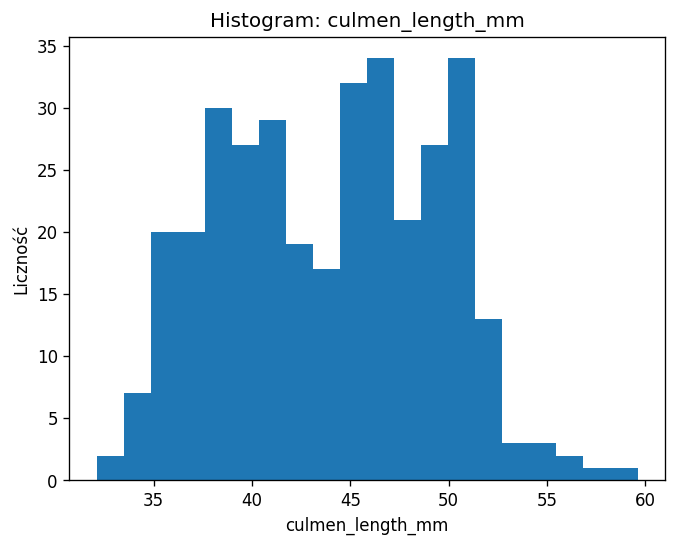

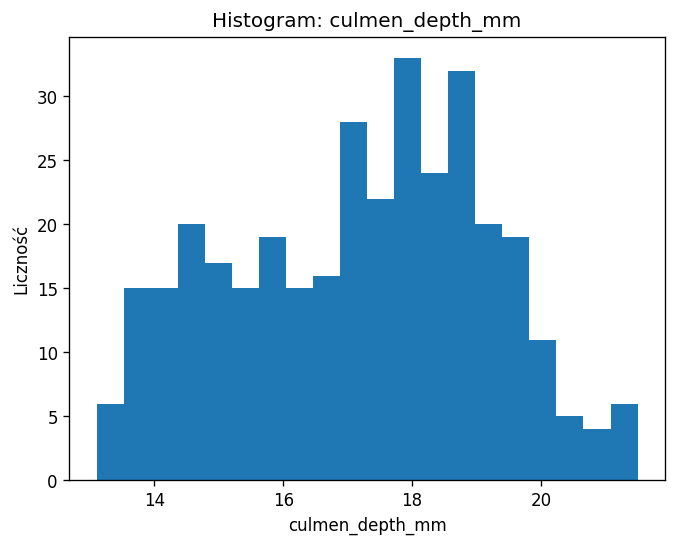

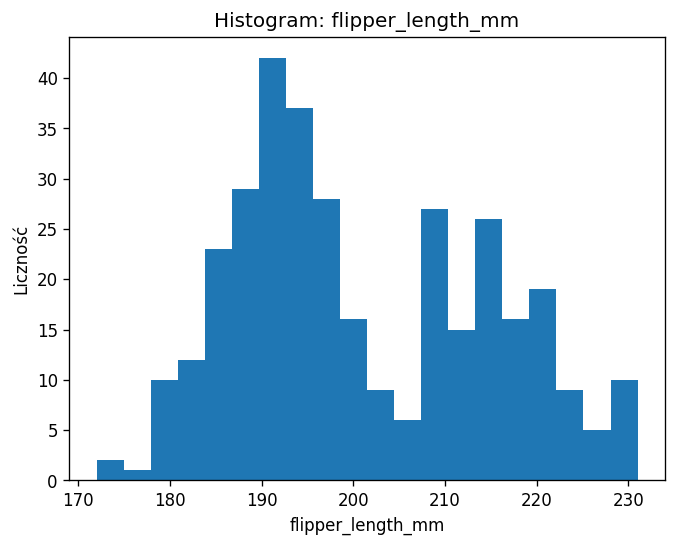

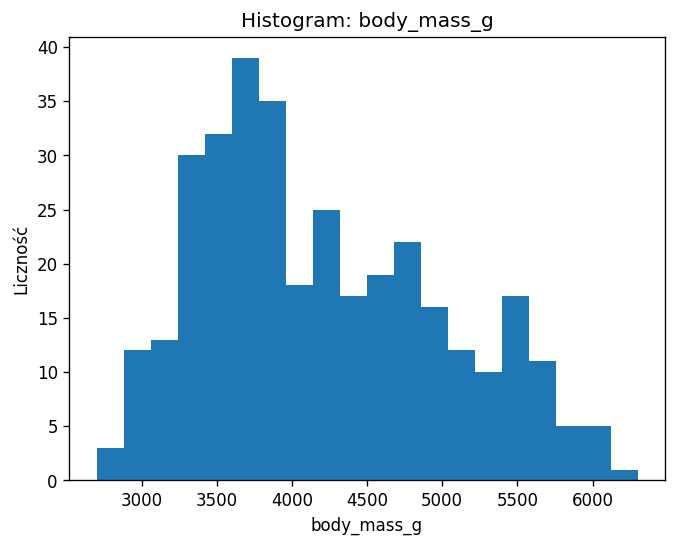

In [14]:
for col in num_cols:
    plt.figure()
    plt.hist(df_measure[col], bins=20)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczność")
    plt.show()

/var/folders/bj/kvg_20p12qz9hlpp8m41sk8m0000gn/T/ipykernel_15345/3772915464.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species_levels)


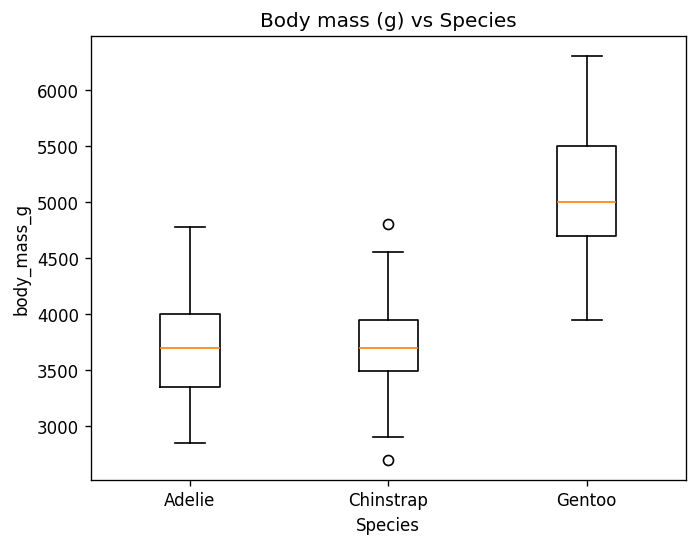

In [15]:
# masa vs gatunek (df_measure - nie wymaga sex)
plt.figure()
species_levels = list(df_measure["species"].cat.categories)
data = [df_measure.loc[df_measure["species"] == s, "body_mass_g"] for s in species_levels]
plt.boxplot(data, labels=species_levels)
plt.title("Body mass (g) vs Species")
plt.xlabel("Species")
plt.ylabel("body_mass_g")
plt.show()

/var/folders/bj/kvg_20p12qz9hlpp8m41sk8m0000gn/T/ipykernel_15345/3329519017.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sex_levels)


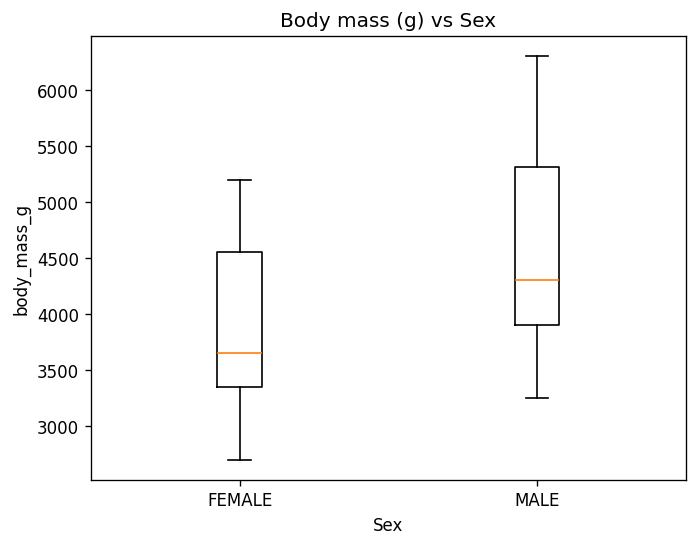

In [16]:
# masa vs płeć (df_sex - wymaga sex)
plt.figure()
sex_levels = list(df_sex["sex"].cat.categories)
data = [df_sex.loc[df_sex["sex"] == s, "body_mass_g"] for s in sex_levels]
plt.boxplot(data, labels=sex_levels)
plt.title("Body mass (g) vs Sex")
plt.xlabel("Sex")
plt.ylabel("body_mass_g")
plt.show()

## 5. Dystrybuanta empiryczna (ECDF)

ECDF pozwala zobaczyć „narastający” rozkład wartości i bywa wygodne do porównań.

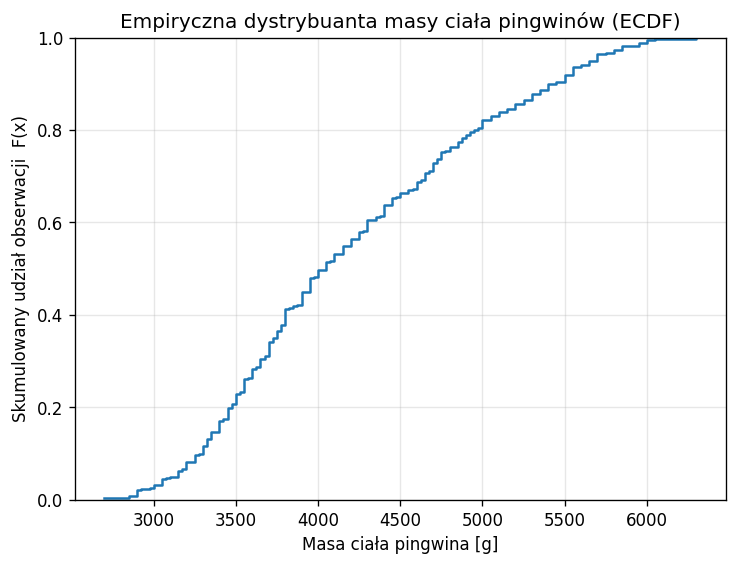

In [195]:
# Empiryczna dystrybuanta (ECDF) masy ciała pingwinów

def ecdf(x):
    x = np.sort(np.array(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(7, 5))

x_ecdf, y_ecdf = ecdf(df_measure["body_mass_g"])
plt.step(x_ecdf, y_ecdf, where="post")

plt.title("Empiryczna dystrybuanta masy ciała pingwinów (ECDF)")
plt.xlabel("Masa ciała pingwina [g]")
plt.ylabel("Skumulowany udział obserwacji  F(x)")
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.show()

Dystrybuanta empiryczna (ECDF) pozwoliła ocenić rozkład masy ciała pingwinów
bez przyjmowania założeń parametrycznych oraz wskazać wartości percentylowe,
co stanowiło wstęp do dalszych analiz statystycznych.

## 6. Estymacja przedziałowa

Wyznaczamy 95% przedziały ufności dla:
- średniej masy ciała (rozkład t-Studenta),
- wariancji masy ciała (rozkład χ²).

In [18]:
# CI dla średniej
x = df_measure["body_mass_g"].to_numpy()
n = len(x)
x_mean = np.mean(x)
x_std = np.std(x, ddof=1)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
margin = t_crit * x_std / np.sqrt(n)

ci_mean = (x_mean - margin, x_mean + margin)
x_mean, x_std, n, ci_mean

(np.float64(4201.754385964912),
 np.float64(801.9545356980955),
 342,
 (np.float64(4116.458332024052), np.float64(4287.050439905773)))

In [19]:
# CI dla wariancji
s2 = np.var(x, ddof=1)
dfree = n - 1

chi2_low = stats.chi2.ppf(alpha/2, df=dfree)
chi2_high = stats.chi2.ppf(1 - alpha/2, df=dfree)

ci_var = (dfree * s2 / chi2_high, dfree * s2 / chi2_low)
s2, ci_var

(np.float64(643131.0773267479),
 (np.float64(556545.1942195788), np.float64(751735.727337233)))

In [20]:
print("95% PRZEDZIAŁY UFNOŚCI\n")

print(f"Średnia masy ciała:")
print(f"  x̄ = {x_mean:.2f} g")
print(f"  95% CI: [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}] g\n")

print(f"Wariancja masy ciała:")
print(f"  s² = {s2:.2f} g²")
print(f"  95% CI: [{ci_var[0]:.2f}, {ci_var[1]:.2f}] g²")

95% PRZEDZIAŁY UFNOŚCI

Średnia masy ciała:
  x̄ = 4201.75 g
  95% CI: [4116.46, 4287.05] g

Wariancja masy ciała:
  s² = 643131.08 g²
  95% CI: [556545.19, 751735.73] g²


In [21]:
#Rozkład płci w gatunkach 
cross_tab = pd.crosstab(df['species'], df['sex'], margins=True)
print("Rozkład płci w gatunkach:")
print(cross_tab)
print("\nProporcje płci w gatunkach:")
print(pd.crosstab(df['species'], df['sex'], normalize='index').round(3))

Rozkład płci w gatunkach:
sex        FEMALE  MALE  All
species                     
Adelie         73    73  146
Chinstrap      34    34   68
Gentoo         58    61  119
All           165   168  333

Proporcje płci w gatunkach:
sex        FEMALE   MALE
species                 
Adelie      0.500  0.500
Chinstrap   0.500  0.500
Gentoo      0.487  0.513


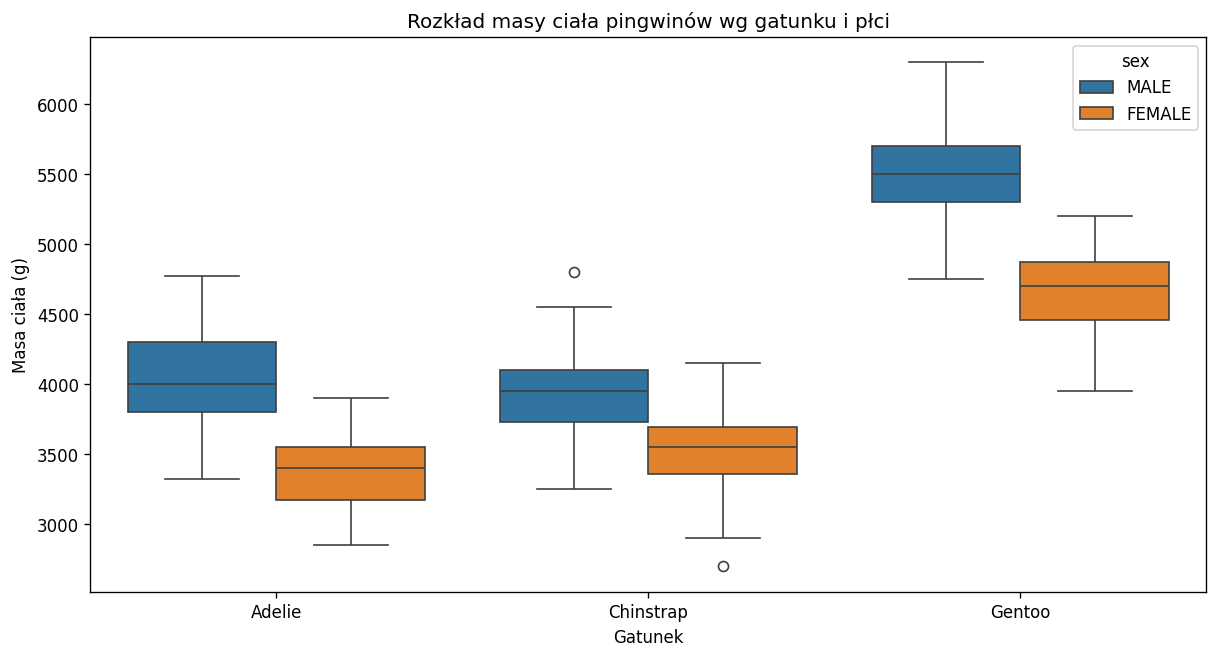

In [25]:
# Boxplot: Masa ciała vs Gatunek, z podziałem na płeć
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex')
plt.title('Rozkład masy ciała pingwinów wg gatunku i płci')
plt.ylabel('Masa ciała (g)')
plt.xlabel('Gatunek')
plt.show()

# Testy parametryczne

In [26]:
# Testy dla każdego gatunku osobno
results_ttest = {}
for species in df['species'].unique():
    df_species = df[df['species'] == species]
    
    # Podział na grupy
    male_mass = df_species[df_species['sex'] == 'MALE']['body_mass_g']
    female_mass = df_species[df_species['sex'] == 'FEMALE']['body_mass_g']
    
    # Test normalności Shapiro-Wilk dla każdej grupy
    shapiro_male = stats.shapiro(male_mass)
    shapiro_female = stats.shapiro(female_mass)
    
    # Test równości wariancji Levene'a
    levene_test = stats.levene(male_mass, female_mass)
    
    # Dobór testu t
    if shapiro_male.pvalue > 0.05 and shapiro_female.pvalue > 0.05:
        # Dane normalne - sprawdzamy wariancje
        if levene_test.pvalue > 0.05:
            t_stat, p_val = stats.ttest_ind(male_mass, female_mass, equal_var=True)
            test_type = 't-test (równe wariancje)'
        else:
            t_stat, p_val = stats.ttest_ind(male_mass, female_mass, equal_var=False)
            test_type = 'Welch t-test (różne wariancje)'
    else:
        # Dane nienormalne - test nieparametryczny
        t_stat, p_val = stats.mannwhitneyu(male_mass, female_mass)
        test_type = 'Mann-Whitney U'
    
    results_ttest[species] = {
        'test_type': test_type,
        't_statistic': t_stat,
        'p_value': p_val,
        'mean_male': male_mass.mean(),
        'mean_female': female_mass.mean(),
        'diff_mean': male_mass.mean() - female_mass.mean(),
        'n_male': len(male_mass),
        'n_female': len(female_mass)
    }

# Prezentacja wyników
for species, res in results_ttest.items():
    print(f"\n{'='*60}")
    print(f"GATUNEK: {species}")
    print(f"{'='*60}")
    print(f"Test: {res['test_type']}")
    print(f"Średnia masa samców: {res['mean_male']:.1f} g (n={res['n_male']})")
    print(f"Średnia masa samic: {res['mean_female']:.1f} g (n={res['n_female']})")
    print(f"Różnica średnich: {res['diff_mean']:.1f} g")
    print(f"Statystyka testowa: {res['t_statistic']:.4f}")
    print(f"p-value: {res['p_value']:.6f}")
    print(f"Wniosek: {'Istotna różnica' if res['p_value'] < 0.05 else 'Brak istotnej różnicy'}")


GATUNEK: Adelie
Test: t-test (równe wariancje)
Średnia masa samców: 4043.5 g (n=73)
Średnia masa samic: 3368.8 g (n=73)
Różnica średnich: 674.7 g
Statystyka testowa: 13.1263
p-value: 0.000000
Wniosek: Istotna różnica

GATUNEK: Chinstrap
Test: t-test (równe wariancje)
Średnia masa samców: 3939.0 g (n=34)
Średnia masa samic: 3527.2 g (n=34)
Różnica średnich: 411.8 g
Statystyka testowa: 5.2077
p-value: 0.000002
Wniosek: Istotna różnica

GATUNEK: Gentoo
Test: t-test (równe wariancje)
Średnia masa samców: 5484.8 g (n=61)
Średnia masa samic: 4679.7 g (n=58)
Różnica średnich: 805.1 g
Statystyka testowa: 14.7217
p-value: 0.000000
Wniosek: Istotna różnica


# Testy nieparametryczne

In [27]:
print("\n" + "="*60)
print("TEST CHI-KWADAT NIEZALEŻNOŚCI")
print("Gatunek vs Wyspa")
print("="*60)

# Tabela krzyżowa
contingency_table = pd.crosstab(df['species'], df['island'])
print("Tabela kontyngencji:")
print(contingency_table)
print()

# Test chi-kwadrat
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Statystyka χ²: {chi2:.4f}")
print(f"Stopnie swobody: {dof}")
print(f"p-value: {p:.6f}")
print(f"Oczekiwane częstotliwości (jeśli niezależne):")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(1))

# Sprawdzenie założeń
# Zasada: nie więcej niż 20% komórek z oczekiwanymi <5
n_cells = expected.size
low_expected = (expected < 5).sum()
prop_low = low_expected / n_cells

print(f"\nZałożenia testu:")
print(f"Komórki z oczekiwanymi <5: {low_expected}/{n_cells} ({prop_low:.1%})")
if prop_low > 0.2:
    print("UWAGA: Ponad 20% komórek ma oczekiwane <5! Rozważ test dokładny Fishera.")
    # Test dokładny Fishera dla tabel 2x2 lub symulacja dla większych
    if contingency_table.shape == (2, 2):
        oddsratio, p_fisher = stats.fisher_exact(contingency_table)
        print(f"Test Fishera, p-value: {p_fisher:.6f}")
else:
    print("Założenie spełnione - mniej niż 20% komórek z oczekiwanymi <5.")

# Miary siły związku
# Współczynnik V Craméra
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"\nMiara siły związku - V Craméra: {cramers_v:.3f}")
print("Interpretacja V Craméra: 0.1 - słaby, 0.3 - umiarkowany, 0.5 - silny")


TEST CHI-KWADAT NIEZALEŻNOŚCI
Gatunek vs Wyspa
Tabela kontyngencji:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

Statystyka χ²: 299.5503
Stopnie swobody: 4
p-value: 0.000000
Oczekiwane częstotliwości (jeśli niezależne):
island     Biscoe  Dream  Torgersen
species                            
Adelie       74.2   54.8       23.0
Chinstrap    33.2   24.5       10.3
Gentoo       60.6   44.7       18.7

Założenia testu:
Komórki z oczekiwanymi <5: 0/9 (0.0%)
Założenie spełnione - mniej niż 20% komórek z oczekiwanymi <5.

Miara siły związku - V Craméra: 0.660
Interpretacja V Craméra: 0.1 - słaby, 0.3 - umiarkowany, 0.5 - silny


# ANOVA

In [28]:
# Przygotowanie danych do ANCOVA/ANOVA dwuczynnikowej
# Najpierw dwuczynnikowa ANOVA (gatunek + płeć + interakcja)
model = ols('body_mass_g ~ C(species) + C(sex) + C(species):C(sex)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Dwuczynnikowa analiza wariancji (ANOVA)")
print(anova_table)

# Testowanie istotności interakcji
if anova_table.loc['C(species):C(sex)', 'PR(>F)'] < 0.05:
    print("\nISTOTNA INTERAKCJA między gatunkiem a płcią!")
    print("Oznacza to, że wpływ płci na masę ciała ZALEŻY od gatunku.")
    print("Należy analizować każdy gatunek osobno (jak w Kroku 3).")
else:
    print("\nBRAK istotnej interakcji między gatunkiem a płcią.")
    print("Można interpretować główne efekty osobno.")
    
# Testy post-hoc Tukeya jeśli potrzebne
if anova_table.loc['C(species)', 'PR(>F)'] < 0.05:
    print("\nTest post-hoc Tukeya dla gatunków:")
    tukey = pairwise_tukeyhsd(endog=df['body_mass_g'], groups=df['species'], alpha=0.05)
    print(tukey)

Dwuczynnikowa analiza wariancji (ANOVA)
                         sum_sq     df           F         PR(>F)
C(species)         1.434016e+08    2.0  749.015666  8.144406e-123
C(sex)             3.709026e+07    1.0  387.459976   1.902273e-57
C(species):C(sex)  1.676557e+06    2.0    8.756997   1.973489e-04
Residual           3.130263e+07  327.0         NaN            NaN

ISTOTNA INTERAKCJA między gatunkiem a płcią!
Oznacza to, że wpływ płci na masę ciała ZALEŻY od gatunku.
Należy analizować każdy gatunek osobno (jak w Kroku 3).

Test post-hoc Tukeya dla gatunków:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
  group1    group2  meandiff p-adj lower upper reject
-----------------------------------------------------
   Adelie Chinstrap      nan   nan   nan   nan  False
   Adelie    Gentoo      nan   nan   nan   nan  False
Chinstrap    Gentoo      nan   nan   nan   nan  False
-----------------------------------------------------
